In [2]:
import xml.etree.ElementTree as ET
import pandas as pd
from pathlib import Path

outdir = Path.cwd().parent / "results" / "traffic_simulation_results" / "run_20251010_133531_baseline" 
newdir = Path.cwd().parent / "results" / "traffic_simulation_results" / "run_20251011-010305"

print(outdir.exists())
print(newdir.exists())

True
True


In [2]:
def parse_summary(path):
    tree = ET.parse(path)
    root = tree.getroot()
    rows = []
    for step in root.iter("step"):
        rec = {}
        for k, v in step.attrib.items():
            try:
                rec[k] = float(v)
            except:
                rec[k] = v
        rows.append(rec)
    df = pd.DataFrame(rows)
    last = df.iloc[-1].to_dict() if not df.empty else {}
    return df, {
        "last_time": last.get("time"),
        "arrived_total": last.get("arrived"),
        "ended_total": last.get("ended"),
        "teleports_total": last.get("teleports"),
        "running": last.get("running"),
        "waiting": last.get("waiting"),
        "mean_speed_avg": float(df["meanSpeed"].replace(-1, pd.NA).dropna().mean()) if "meanSpeed" in df else None,
        "mean_travel_time_last": last.get("meanTravelTime"),
        "mean_waiting_time_avg": float(df["meanWaitingTime"].mean()) if "meanWaitingTime" in df else None,
        "steps": len(df),
    }

def parse_detector_totals(path):
    tree = ET.parse(path)
    root = tree.getroot()
    totals_by_id = {}
    count_rows = 0
    speed_sum = 0.0
    speed_count = 0
    total_nVehEntered = 0.0
    total_nVehContrib = 0.0
    for it in root.iter("interval"):
        count_rows += 1
        id_ = it.attrib.get("id")
        nve = float(it.attrib.get("nVehEntered", "0"))
        nvc = float(it.attrib.get("nVehContrib", "0"))
        spd = float(it.attrib.get("speed", "-1"))
        total_nVehEntered += nve
        total_nVehContrib += nvc
        if spd >= 0:
            speed_sum += spd
            speed_count += 1
        if id_ not in totals_by_id:
            totals_by_id[id_] = {"id": id_, "nVehEntered": 0.0, "nVehContrib": 0.0, "flow": 0.0}
        totals_by_id[id_]["nVehEntered"] += nve
        totals_by_id[id_]["nVehContrib"] += nvc
        try:
            totals_by_id[id_]["flow"] += float(it.attrib.get("flow", "0"))
        except:
            pass
    by_id_df = pd.DataFrame(list(totals_by_id.values()))
    avg_speed = (speed_sum / speed_count) if speed_count else None
    return by_id_df, {
        "interval_rows": count_rows,
        "detector_count": by_id_df["id"].nunique() if not by_id_df.empty else 0,
        "total_nVehEntered_all_detectors": total_nVehEntered,
        "total_nVehContrib_all_detectors": total_nVehContrib,
        "avg_speed_all_rows": avg_speed,
    }


paths = {
    "baseline_summary": str(outdir / "summary.xml"),
    "baseline_detector": str(outdir / "detector_output.xml"),
    "new_summary": str(newdir / "summary.xml"),
    "new_detector": str(newdir / "detector_output.xml"),
}

# Parse files
b_sum_df, b_sum = parse_summary(paths["baseline_summary"])
n_sum_df, n_sum = parse_summary(paths["new_summary"])
b_det_df, b_det = parse_detector_totals(paths["baseline_detector"])
n_det_df, n_det = parse_detector_totals(paths["new_detector"])

def row(metric, b, n):
    try:
        delta = (n - b) if (b is not None and n is not None) else None
    except TypeError:
        delta = None
    return {"metric": metric, "baseline": b, "new": n, "delta (new - base)": delta}

comp_rows = [
    row("Simulation end time (s)", b_sum["last_time"], n_sum["last_time"]),
    row("Total arrived vehicles", b_sum["arrived_total"], n_sum["arrived_total"]),
    row("Total teleports", b_sum["teleports_total"], n_sum["teleports_total"]),
    row("Vehicles still running at end", b_sum["running"], n_sum["running"]),
    row("Vehicles waiting at end", b_sum["waiting"], n_sum["waiting"]),
    row("Avg. mean speed over steps (m/s)", b_sum["mean_speed_avg"], n_sum["mean_speed_avg"]),
    row("Mean travel time at end (s)", b_sum["mean_travel_time_last"], n_sum["mean_travel_time_last"]),
    row("Avg. mean waiting time over steps (s)", b_sum["mean_waiting_time_avg"], n_sum["mean_waiting_time_avg"]),
    row("# summary steps", b_sum["steps"], n_sum["steps"]),
    row("Detector interval rows", b_det["interval_rows"], n_det["interval_rows"]),
    row("Detector count", b_det["detector_count"], n_det["detector_count"]),
    row("Total nVehEntered across detectors", b_det["total_nVehEntered_all_detectors"], n_det["total_nVehEntered_all_detectors"]),
    row("Total nVehContrib across detectors", b_det["total_nVehContrib_all_detectors"], n_det["total_nVehContrib_all_detectors"]),
    row("Avg detector speed over intervals (m/s)", b_det["avg_speed_all_rows"], n_det["avg_speed_all_rows"]),
]

comp_df = pd.DataFrame(comp_rows)

# Per-detector detail
per_det = pd.merge(b_det_df, n_det_df, on="id", how="outer", suffixes=("_base","_new")).fillna(0)
per_det["delta_nVehEntered"] = per_det["nVehEntered_new"] - per_det["nVehEntered_base"]
per_det["delta_nVehContrib"] = per_det["nVehContrib_new"] - per_det["nVehContrib_base"]
per_det["delta_flow"] = per_det["flow_new"] - per_det["flow_base"]

# Save CSVs
out1 = newdir / "network_comparison_summary.csv"
out2 = newdir / "per_detector_comparison.csv"
comp_df.to_csv(out1, index=False)
per_det.to_csv(out2, index=False)

print("Wrote:", out1.resolve())
print("Wrote:", out2.resolve())


Wrote: C:\Users\hanju\OneDrive - AUT University\01. Papers\09. Dissertation\4.0 Projects\xai-traffic-prediction\results\traffic_simulation_results\run_20251011-010305\network_comparison_summary.csv
Wrote: C:\Users\hanju\OneDrive - AUT University\01. Papers\09. Dissertation\4.0 Projects\xai-traffic-prediction\results\traffic_simulation_results\run_20251011-010305\per_detector_comparison.csv


In [12]:
import pandas as pd
newdir = Path.cwd().parent / "results" / "traffic_simulation_results" / "run_20251013-170024"
network_comparison_df = pd.read_csv(newdir / "network_comparison_summary.csv")
detector_comparison_df = pd.read_csv(newdir / "per_detector_comparison.csv")

In [16]:
# =========================
# Display summaries
# =========================

# network_comparison_df['conclusion'] = ["Improved" if x > 0 else "Worsened" for x in network_comparison_df['delta (new - base)']]
network_comparison_df[['metric', 'baseline', 'new', 'improved']]

,metric,baseline,new,improved
0,Simulation end time (s),3599.000000,3599.000000,3599.000000
1,Total arrived vehicles,1647.000000,1920.000000,2276.000000
2,Total teleports,58.000000,6.000000,0.000000
3,Vehicles still running at end,129.000000,120.000000,97.000000
4,Vehicles waiting at end,3916.000000,3652.000000,3319.000000
5,Avg. mean speed over steps (m/s),1.323300,1.645911,2.224394
6,Mean travel time at end (s),222.940000,196.260000,166.440000
7,Avg. mean waiting time over steps (s),359.352508,459.408136,408.807544
8,# summary steps,3600.000000,3600.000000,3600.000000
9,Detector interval rows,996.000000,996.000000,996.000000


In [20]:
# =========================
# Display per-detector detail
# =========================

# detector_comparison_df['conclusion'] = ["Improved" if x > 0 else "Worsened" for x in detector_comparison_df['delta_flow']]
detector_comparison_df[['id', 'flow_base', 'flow_new', 'flow_impr']]
# detector_comparison_df[['id', 'Δ_flow(new−base)', 'Δ_flow(impr−new)', 'Δ_flow(impr−base)']]

,id,flow_base,flow_new,flow_impr
0,loop_-1088700963_0,60480.0,50520.0,17580.0
1,loop_-1286470869#1_0,47160.0,39660.0,15000.0
2,loop_-13718894_0,6180.0,16800.0,39120.0
3,loop_-13718894_1,4200.0,6360.0,17580.0
4,loop_-624523286_0,12.0,2604.0,2604.0
5,loop_-7637536#1_0,2400.0,2940.0,2340.0
6,loop_119880451_0,4128.0,4128.0,3156.0
7,loop_119880453#0_0,5040.0,12960.0,20820.0
8,loop_1246214209#0_0,0.0,0.0,540.0
9,loop_1246214209#0_1,1320.0,3660.0,4860.0


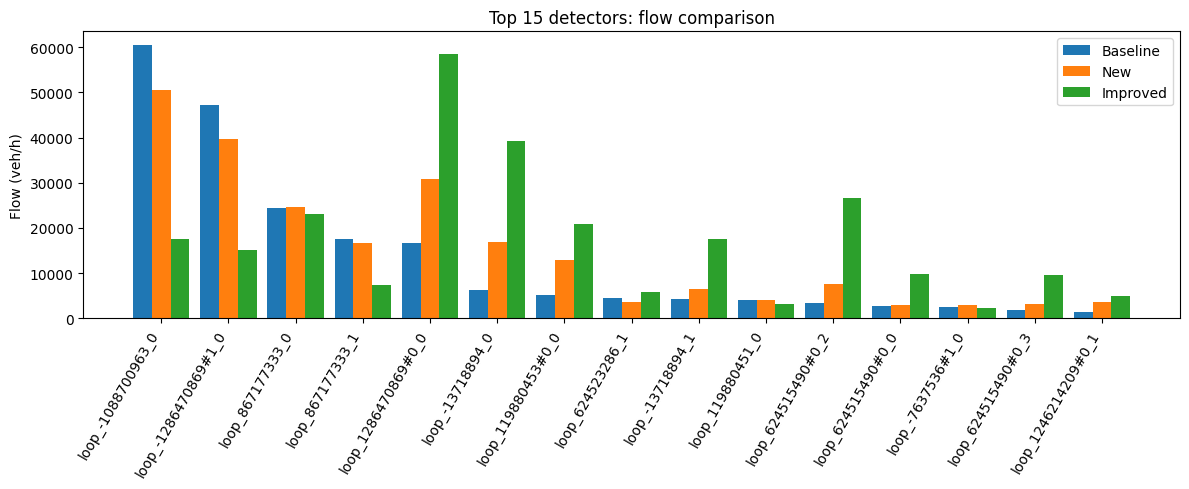

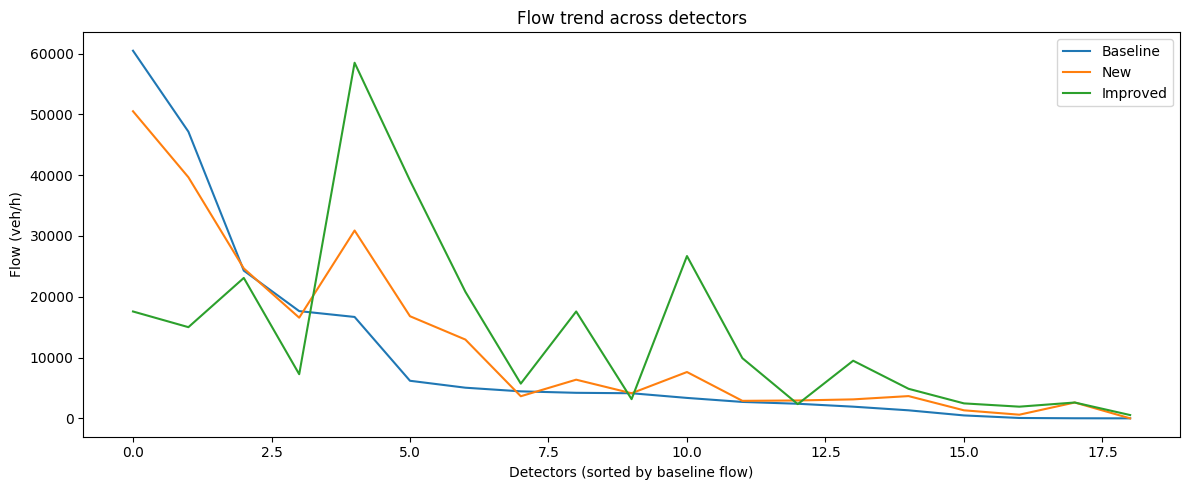

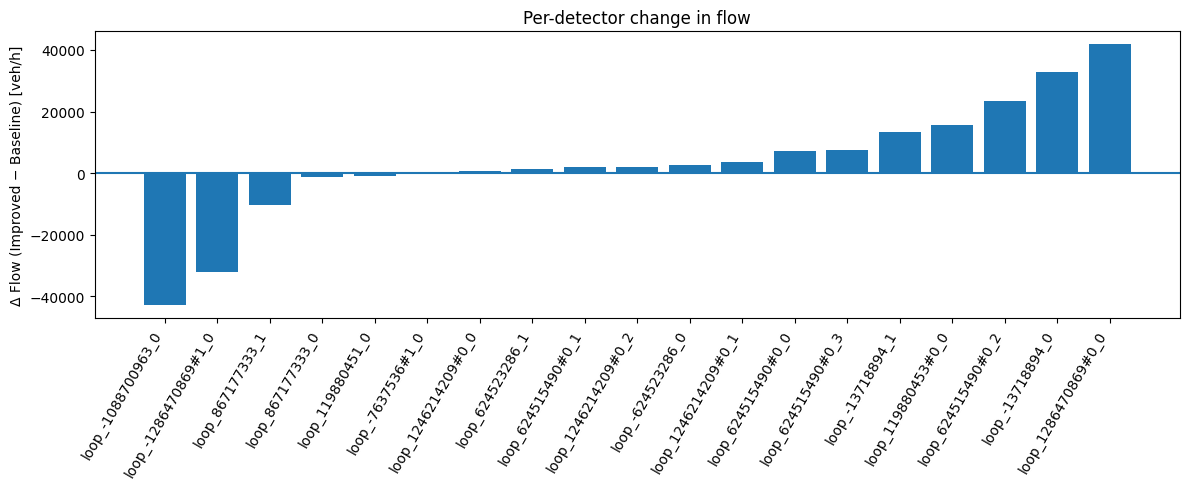

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# If needed: df = pd.read_csv("per_detector_comparison.csv", usecols=["id","flow_base","flow_new","flow_impr"])

# 1) Grouped bars (Top-N busiest detectors by baseline flow)
N = 15
top = detector_comparison_df.sort_values("flow_base", ascending=False).head(N)
x = np.arange(len(top))
width = 0.28

plt.figure(figsize=(12,5))
plt.bar(x - width, top["flow_base"].values, width, label="Baseline")
plt.bar(x,          top["flow_new"].values,  width, label="New")
plt.bar(x + width,  top["flow_impr"].values, width, label="Improved")
plt.xticks(x, top["id"].astype(str), rotation=60, ha="right")
plt.ylabel("Flow (veh/h)")
plt.title(f"Top {N} detectors: flow comparison")
plt.legend()
plt.tight_layout()
plt.show()

# 2) Line trend across all detectors (sorted by baseline flow)
sorted_df = detector_comparison_df.sort_values("flow_base", ascending=False).reset_index(drop=True)
plt.figure(figsize=(12,5))
plt.plot(sorted_df["flow_base"].values,  label="Baseline")
plt.plot(sorted_df["flow_new"].values,   label="New")
plt.plot(sorted_df["flow_impr"].values,  label="Improved")
plt.xlabel("Detectors (sorted by baseline flow)")
plt.ylabel("Flow (veh/h)")
plt.title("Flow trend across detectors")
plt.legend()
plt.tight_layout()
plt.show()

# 3) Delta bars (improved - baseline) to see where you gained/lost most
delta = detector_comparison_df.assign(delta_impr_base=detector_comparison_df["flow_impr"] - detector_comparison_df["flow_base"]) \
          .sort_values("delta_impr_base")
plt.figure(figsize=(12,5))
plt.bar(range(len(delta)), delta["delta_impr_base"].values)
plt.xticks(range(len(delta)), delta["id"].astype(str), rotation=60, ha="right")
plt.axhline(0)
plt.ylabel("Δ Flow (Improved − Baseline) [veh/h]")
plt.title("Per-detector change in flow")
plt.tight_layout()
plt.show()


In [26]:
delta[['id','flow_base','flow_new','flow_impr','delta_impr_base']]

,id,flow_base,flow_new,flow_impr,delta_impr_base
0,loop_-1088700963_0,60480.0,50520.0,17580.0,-42900.0
1,loop_-1286470869#1_0,47160.0,39660.0,15000.0,-32160.0
18,loop_867177333_1,17640.0,16560.0,7260.0,-10380.0
17,loop_867177333_0,24300.0,24660.0,23100.0,-1200.0
6,loop_119880451_0,4128.0,4128.0,3156.0,-972.0
5,loop_-7637536#1_0,2400.0,2940.0,2340.0,-60.0
8,loop_1246214209#0_0,0.0,0.0,540.0,540.0
16,loop_624523286_1,4440.0,3636.0,5712.0,1272.0
13,loop_624515490#0_1,60.0,600.0,1920.0,1860.0
10,loop_1246214209#0_2,480.0,1320.0,2460.0,1980.0
